<a href="https://colab.research.google.com/github/csataridominik/ML_Projects/blob/main/cifar_10_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import torch
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
from torch.utils.data import Dataset, dataloader, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import confusion_matrix

import seaborn as sns

In [25]:
writer = SummaryWriter("runs")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

cuda


In [26]:

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

In [27]:
len(trainset)

50000

This is a bird.


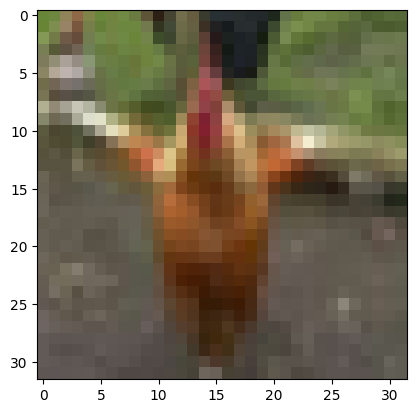

In [28]:
idx = np.random.randint(0,len(trainset))
print(f'This is a {trainset.classes[trainset.targets[idx]]}.')
plt.imshow(trainset.data[idx])
plt.show()


In [29]:
# Stratified dataloaders:
batch_size = 16

train_idx, valid_idx= train_test_split(
np.arange(len(trainset.targets)),
test_size=0.2,
shuffle=True,
stratify=trainset.targets)

train_sampler = torch.utils.data.SubsetRandomSampler(train_idx)
valid_sampler = torch.utils.data.SubsetRandomSampler(valid_idx)

train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, sampler=train_sampler)
valid_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, sampler=valid_sampler)

In [30]:
next(iter(train_loader))[0].shape

torch.Size([16, 3, 32, 32])

In [45]:
class Model(nn.Module):
  def __init__(self,classes = 16) -> None:
    super().__init__()
    self.classes = classes

    self.conv1 = nn.Conv2d(3,8,3) # [b,3,32,32] -> [b,8,30,30]
    self.conv2 = nn.Conv2d(8,16,3) # [b,8,30,30] -> [b,16,28,28]
    self.conv3 = nn.Conv2d(16,32,5) # [b,16,28,28] -> [b,32,24,24]
    self.conv4 = nn.Conv2d(32,64,5) # [b,32,24,24] -> [b,64,20,20]
    self.conv5 = nn.Conv2d(64,128,5) #  -> [b,128,16,16]
    self.conv6 = nn.Conv2d(128,256,5) # -> [b,256,12,12]


    self.pooling_layer = nn.AdaptiveAvgPool2d((1,1)) # [b,256,12,12] -> [b,256,1,1]
    # flatten

    self.MLP = nn.Sequential(
        nn.Linear(256,128),
        nn.ReLU(),
        nn.BatchNorm1d(128),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.BatchNorm1d(64),
        nn.Linear(64,self.classes)
    )

    self.bn1 = nn.BatchNorm2d(8)
    self.bn2 = nn.BatchNorm2d(16)
    self.bn3 = nn.BatchNorm2d(32)
    self.bn4 = nn.BatchNorm2d(64)
    self.bn5 = nn.BatchNorm2d(128)
    self.bn6 = nn.BatchNorm2d(256)

    self.act = nn.ReLU()

  def forward(self,x):
    x = self.act(self.bn1(self.conv1(x)))
    x = self.act(self.bn2(self.conv2(x)))
    x = self.act(self.bn3(self.conv3(x)))
    x = self.act(self.bn4(self.conv4(x)))
    x = self.act(self.bn5(self.conv5(x)))
    x = self.act(self.bn6(self.conv6(x)))
    x = self.pooling_layer(x)

    x = torch.flatten(x, 1)

    x = self.MLP(x)

    return x

class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=3, patch_size=4, emb_size=128, img_size=32):
        super().__init__()
        self.patch_size = patch_size
        # Project patches into embedding dimension using a convolution
        self.projection = nn.Conv2d(in_channels, emb_size, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.randn(1, 1, emb_size))
        self.pos_embedding = nn.Parameter(torch.randn((img_size // patch_size)**2 + 1, emb_size))

    def forward(self, x):
        # x: [b, 3, 32, 32] -> [b, emb, 8, 8]
        x = self.projection(x)
        # Flatten spatial dimensions: [b, emb, 64] -> [b, 64, emb]
        x = x.flatten(2).transpose(1, 2)

        # Add CLS token
        b, n, _ = x.shape
        cls_tokens = self.cls_token.expand(b, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)

        # Add Position Embedding
        x += self.pos_embedding
        return x

class Model_ViT(nn.Module):
    def __init__(self, img_size=32, patch_size=8, in_ch=3, n_classes=16,
                 embed_dim=128, depth=2, n_heads=2, mlp_ratio=2.0):
        super().__init__()

        self.patch_embed = PatchEmbedding(in_ch, patch_size, embed_dim, img_size)

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=n_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            activation='gelu',
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        # Classification Head
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, n_classes)
        )

    def forward(self, x):
        x = self.patch_embed(x)

        x = self.transformer(x)

        cls_token_final = x[:, 0]

        return self.mlp_head(cls_token_final)


class Model_Gemini(nn.Module):
    def __init__(self, classes=16) -> None:
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x



def test():
  sample_in = next(iter(train_loader))[0].to(device)
  test_model = Model().to(device)

  out = test_model(sample_in)
  print(out.shape)


In [40]:
'''%reload_ext tensorboard
%tensorboard --logdir runs'''

'%reload_ext tensorboard\n%tensorboard --logdir runs'

In [ ]:
# training loop:
model = Model_Gemini().to(device)
lr = 1e-4
epochs = 50
criterion = nn.CrossEntropyLoss()
opt = torch.optim.AdamW(params=model.parameters(), lr=lr)

steps = 0
for epoch in range(epochs):

    # --- TRAINING PHASE ---
    model.train()
    train_loss_accum = 0.0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        y_pred = model(x)
        loss = criterion(y_pred, y)

        opt.zero_grad()
        loss.backward()
        opt.step()

        train_loss_accum += loss.item()
        steps += 1

    avg_train_loss = train_loss_accum / len(train_loader)
    writer.add_scalar("Loss/train_epoch", avg_train_loss, epoch)

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss_accum = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in valid_loader:
            x, y = x.to(device), y.to(device)
            y_pred = model(x)

            loss = criterion(y_pred, y)
            val_loss_accum += loss.item()

            preds = y_pred.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    avg_val_loss = val_loss_accum / len(valid_loader)
    epoch_acc = np.mean(np.array(all_preds) == np.array(all_labels))

    writer.add_scalar("Loss/validation", avg_val_loss, epoch)
    writer.add_scalar("Accuracy/validation", epoch_acc, epoch)

    # --- CONFUSION MATRIX ---
    cm = confusion_matrix(all_labels, all_preds)
    fig = plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    writer.add_figure("ConfusionMatrix/validation", fig, epoch)
    plt.close(fig)
    writer.flush()

    # --- PRINT LOGS ---
    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val Acc: {epoch_acc:.4f}")

In [ ]:
'''
- Model() -> around 73% validation accuracy at epoch 26
- Model_ViT() -> 63% but it was improving, didnt plateau yet...
- Model_Gemini() -> 75% at epoch 20.

Improve: Augmentation, Cropping, Flipping
'''